In [1]:
import os
from google.colab import userdata
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
data_path = "/content/drive/MyDrive/ADS2002"

Mounted at /content/drive


In [62]:
train_labels = pd.read_csv(f"{data_path}/train_labels.csv")
test_labels = pd.read_csv(f"{data_path}/test_labels.csv")

In [ ]:
!unzip -q "{data_path}/train.zip" -d /content/train_images
!unzip -q "{data_path}/test.zip" -d /content/test_images

In [51]:
train_labels

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0
1,ISIC_0074542,IP_4698288,male,25.0,lower extremity,unknown,benign,0
2,ISIC_0076545,IP_9802602,male,55.0,upper extremity,unknown,benign,0
3,ISIC_0082348,IP_7684360,male,55.0,torso,unknown,benign,0
4,ISIC_0085172,IP_1705144,female,50.0,lower extremity,unknown,benign,0
...,...,...,...,...,...,...,...,...
6859,ISIC_9988492,IP_8173459,female,50.0,torso,unknown,benign,0
6860,ISIC_9990676,IP_3686214,female,55.0,lower extremity,nevus,benign,0
6861,ISIC_9991394,IP_2321962,female,30.0,torso,unknown,benign,0
6862,ISIC_9991967,IP_2507276,male,70.0,lower extremity,nevus,benign,0


In [3]:
print(f"Number of malignant cases: {len(train_labels[train_labels["target"] == 1])}")

Number of malignant cases: 128


In [4]:
train_labels.describe()

,age_approx,target
count,6864.000000,6864.000000
mean,48.944493,0.018648
std,14.401600,0.135288
min,15.000000,0.000000
25%,40.000000,0.000000
50%,50.000000,0.000000
75%,60.000000,0.000000
max,90.000000,1.000000


In [5]:
train_labels.isna().sum()

,0
image_name,0
patient_id,0
sex,0
age_approx,0
anatom_site_general_challenge,196
diagnosis,0
benign_malignant,0
target,0


In [6]:
print(f"Number of unique patients: {len(train_labels) - train_labels["patient_id"].duplicated().sum()}")

Number of unique patients: 422


In [7]:
print(f"Does every 'melanoma' diagnosis correspond to a '1' in a target: {(train_labels[train_labels["diagnosis"] == "melanoma"]["target"] == 1).all()}")

Does every 'melanoma' diagnosis correspond to a '1' in a target: True


In [8]:
test_labels

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_0088489,IP_9147454,female,55.0,torso,unknown,benign,0
1,ISIC_0096201,IP_9906695,female,45.0,torso,nevus,benign,0
2,ISIC_0097500,IP_9147454,female,55.0,upper extremity,unknown,benign,0
3,ISIC_0112444,IP_9147454,female,55.0,torso,unknown,benign,0
4,ISIC_0148465,IP_1517386,male,40.0,head/neck,unknown,benign,0
...,...,...,...,...,...,...,...,...
1983,ISIC_9981394,IP_8352243,female,40.0,upper extremity,unknown,benign,0
1984,ISIC_9998152,IP_4356379,female,40.0,lower extremity,unknown,benign,0
1985,ISIC_9998682,IP_2516168,male,60.0,head/neck,melanoma,malignant,1
1986,ISIC_9999127,IP_9583707,male,20.0,torso,unknown,benign,0


In [9]:
print(f"Number of malignant cases: {len(test_labels[test_labels["target"] == 1])}")

Number of malignant cases: 31


In [10]:
test_labels.describe()

,age_approx,target
count,1988.000000,1988.000000
mean,50.364688,0.015594
std,14.808977,0.123928
min,10.000000,0.000000
25%,40.000000,0.000000
50%,50.000000,0.000000
75%,60.000000,0.000000
max,90.000000,1.000000


In [11]:
test_labels.isna().sum()

,0
image_name,0
patient_id,0
sex,0
age_approx,0
anatom_site_general_challenge,24
diagnosis,0
benign_malignant,0
target,0


In [12]:
print(f"Number of unique patients: {len(test_labels) - test_labels["patient_id"].duplicated().sum()}")

Number of unique patients: 106


In [13]:
print(f"Does every 'melanoma' diagnosis correspond to a '1' in a target: {(test_labels[test_labels["diagnosis"] == "melanoma"]["target"] == 1).all()}")

Does every 'melanoma' diagnosis correspond to a '1' in a target: True


In [14]:
train_patients = set(train_labels['patient_id'])
test_patients = set(test_labels['patient_id'])
overlap = train_patients & test_patients
print(len(overlap))

0


<Axes: xlabel='target', ylabel='age_approx'>

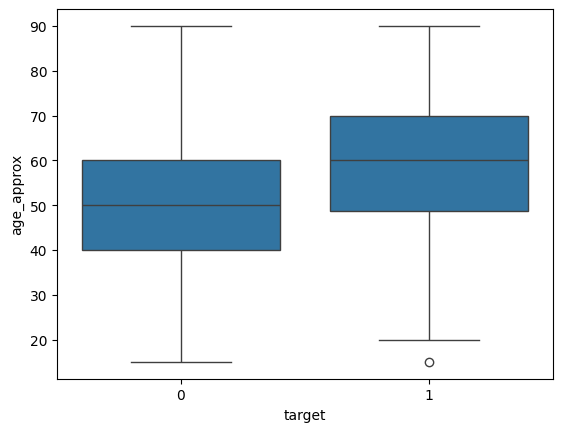

In [16]:
sns.boxplot(data=train_labels, x='target', y='age_approx')

Grouping unique patients

In [34]:
unique_patients = train_labels.groupby("patient_id")["target"].agg(["sum", "count"])
unique_patients.describe()

,sum,count
count,422.000000,422.000000
mean,0.303318,16.265403
std,0.756877,16.568455
min,0.000000,3.000000
25%,0.000000,5.000000
50%,0.000000,12.000000
75%,0.000000,21.750000
max,8.000000,115.000000


In [36]:
# Patients who have 115 entries
unique_patients[unique_patients['count'] == 115]

,sum,count
patient_id,,
IP_4382720,0,115
IP_4938382,1,115


In [32]:
# Patients with more than 1 melanoma spot
unique_patients[unique_patients['sum'] > 1]

,sum,count
patient_id,,
IP_0957064,2,3
IP_1023029,2,38
IP_1122600,2,16
IP_1512731,2,37
IP_2101945,2,17
IP_2412574,5,23
IP_2986217,3,7
IP_3010556,3,4
IP_3045056,2,4


<Axes: title={'center': 'Melanoma Patients Count by Sum'}, xlabel='Melanoma Counts', ylabel='Number of patients'>

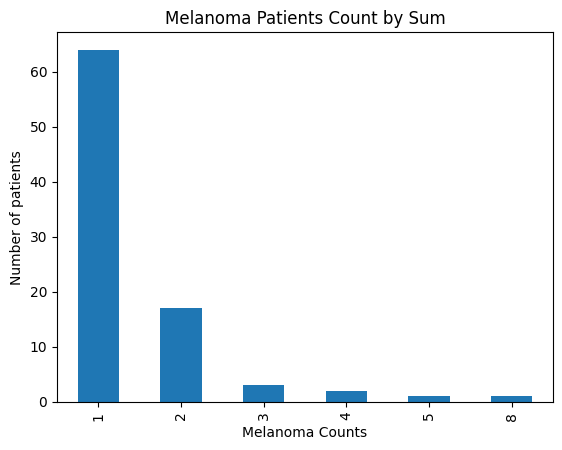

In [46]:
melanoma_patients = unique_patients[unique_patients['sum'] > 0]
melanoma_patients.groupby("sum")["sum"].count().plot.bar(
    xlabel = "Melanoma Counts",
    ylabel = "Number of patients",
    title = "Melanoma Patients Count by Sum"
)

Preprocessing

In [73]:
train_labels_clean = train_labels.copy()
train_labels_clean["sex"] = train_labels["sex"].map({"male": 1, "female": 0})
train_labels_clean["anatom_site_general_challenge"] = train_labels_clean["anatom_site_general_challenge"].fillna("missing")
train_labels_clean = train_labels_clean.drop(["diagnosis", "benign_malignant"], axis=1)
train_labels_clean

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,target
0,ISIC_0015719,IP_3075186,0,45.0,upper extremity,0
1,ISIC_0074542,IP_4698288,1,25.0,lower extremity,0
2,ISIC_0076545,IP_9802602,1,55.0,upper extremity,0
3,ISIC_0082348,IP_7684360,1,55.0,torso,0
4,ISIC_0085172,IP_1705144,0,50.0,lower extremity,0
...,...,...,...,...,...,...
6859,ISIC_9988492,IP_8173459,0,50.0,torso,0
6860,ISIC_9990676,IP_3686214,0,55.0,lower extremity,0
6861,ISIC_9991394,IP_2321962,0,30.0,torso,0
6862,ISIC_9991967,IP_2507276,1,70.0,lower extremity,0


Modeling

In [70]:
from sklearn.linear_model import LogisticRegression

X, y = train_labels_clean.drop(columns=["image_name", "patient_id", "target"]), train_labels_clean["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 80)

clf = LogisticRegression(max_iter = 1000, random_state = 0)
clf.fit(X_train, y_train)

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
13,ISIC_0099474,IP_3057277,1,45.0,missing,unknown,benign,0
42,ISIC_0178744,IP_4248414,1,25.0,missing,unknown,benign,0
64,ISIC_0204994,IP_5549010,0,30.0,missing,nevus,benign,0
82,ISIC_0230516,IP_3057277,1,45.0,missing,unknown,benign,0
102,ISIC_0249212,IP_3057277,1,45.0,missing,unknown,benign,0
...,...,...,...,...,...,...,...,...
6601,ISIC_9586629,IP_3057277,1,45.0,missing,unknown,benign,0
6623,ISIC_9626110,IP_1705144,0,50.0,missing,nevus,benign,0
6645,ISIC_9663140,IP_3057277,1,45.0,missing,unknown,benign,0
6779,ISIC_9866242,IP_3057277,1,45.0,missing,unknown,benign,0
